# СИМА — Бенчмаркинг сервиса рельефа: время и точность ЦМР/ЦММ

Ноутбук измеряет **производительность** и **точность** `sima-relief-service`
на датасете триплетов `test_data/dsm_dataset`.

## Датасет

Триплеты подбираются по имени номенклатурного листа — стему файла ОФП:

| Компонент | Путь | Содержание |
|---|---|---|
| **ОФП** (АФС) | `OFP/<stem>.tif` | ортофотоплан, RGBA, ~0.07 м/пиксель |
| **ВЛС** | `LAS/<stem>_ground_TLO.las` | облако точек, **Z = HeightAboveGround (ТЛО)** |
| **Эталон** | `DSM/<n>/<stem>.tif` | ранее независимо посчитанная ЦМР, 1 м/пиксель |

## Что измеряется

**Время** — по каждому тайлу и каждому шагу конвейера
(`crop → filter → ЦМР → ЦММ → smooth → slope/aspect/TPI → contours/TIN → heights`),
источник — `TileStep.duration_ms` самого сервиса, плюс отдельные замеры
подготовительных операций (оценка материалов, восстановление Z, расчёт метрик).
Каждый выходной артефакт привязан к породившему его шагу; горизонтали
дополнительно замеряются посечённо.

**Точность** — построенная ЦМР (сырая и сглаженная) против эталона:
ME (систематический сдвиг), MAE, RMSE, NMAD (робастная σ), P95 |Δ|, покрытие.
Критерий проекта: относительная ошибка `RMSE / mean(Z эталона) < 5 %`.

---

## ⚠️ Ограничение методологии — обязательно к прочтению

ВЛС в датасете хранит **ТЛО** — нормализованные высоты (`Z = HeightAboveGround`,
диапазон ≈ −1…+25 м), а не абсолютные отметки. Чтобы вообще запустить построение
ЦМР, абсолютные Z приходится восстанавливать **по эталонной ЦМР**
(`relief_bench.restore_absolute`): ground-точки получают Z эталона в своей ячейке,
остальные — Z эталона + ТЛО. Это тот же приём, что и в `relief_demo.ipynb`
(`tests/fixtures/restore_las.py`).

Следствие: **сравнение с эталоном не является независимой валидацией точности
съёмки.** Оно измеряет точность *реконструкции поверхности сервисом* —
цепочки «SMRF-классификация ground → IDW-растеризация → заполнение дыр →
сглаживание», — то есть сколько сервис теряет на roundtrip
`эталон → точки → эталон`. Это нижняя граница ошибки: реальная ошибка на
абсолютных ВЛС будет выше на величину ошибки самих измерений.

Числа RMSE ниже читать именно так. Для полноценной валидации нужны ВЛС с
абсолютными Z (не ТЛО) либо независимые контрольные точки (GNSS-пикеты).

У **ЦММ (DSM)** эталона в датасете нет вовсе, поэтому для неё считается не
ошибка, а описательная статистика и разность `ЦММ − ЦМР` — высота растительности
и объектов над землёй.

## 1. Настройка

In [1]:
import json, os, sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

BACKEND = Path('/Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend')
DATASET_ROOT = '/Users/sergeyzay/Documents/НЕДРА/СИМА/test_data/dsm_dataset'
RESULTS_DIR = BACKEND / 'benchmarks' / 'results'
RESULTS_PATH = RESULTS_DIR / 'results.jsonl'

# Перезапуск полного прогона (≈40 мин на 123 триплета). False — читать готовый JSONL.
RUN_BENCHMARK = False
LIMIT = None            # ограничить число триплетов при перезапуске

sys.path.insert(0, str(BACKEND / 'benchmarks'))
import relief_bench as RB

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110

print('relief_bench загружен из', RB.__file__)

relief_bench загружен из /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/relief_bench.py


## 2. Отбор триплетов

Пересечение по стему ОФП: `OFP ∩ LAS ∩ DSM`.

In [2]:
triplets = RB.find_triplets(DATASET_ROOT)

n_ofp = len(list((Path(DATASET_ROOT) / 'OFP').glob('*.tif')))
n_las = len(list((Path(DATASET_ROOT) / 'LAS').glob('*.las')))
n_dsm = len(list((Path(DATASET_ROOT) / 'DSM').rglob('*.tif')))

print(f'ОФП файлов:        {n_ofp}')
print(f'ВЛС файлов:        {n_las}')
print(f'Эталонов ЦМР:      {n_dsm}')
print(f'Полных триплетов:  {len(triplets)}')
print()
pd.DataFrame([{'name': t.name,
               'OFP': Path(t.ofp).name,
               'LAS': Path(t.las).name,
               'ЭТАЛОН': str(Path(t.ref).relative_to(DATASET_ROOT))}
              for t in triplets]).head(10)

ОФП файлов:        354
ВЛС файлов:        132
Эталонов ЦМР:      370
Полных триплетов:  123



,name,OFP,LAS,ЭТАЛОН
0,P-42-041-239-e,P-42-041-239-e.tif,P-42-041-239-e_ground_TLO.las,DSM/246/P-42-041-239-e.tif
1,P-42-041-239-f,P-42-041-239-f.tif,P-42-041-239-f_ground_TLO.las,DSM/246/P-42-041-239-f.tif
2,P-42-041-239-g,P-42-041-239-g.tif,P-42-041-239-g_ground_TLO.las,DSM/246/P-42-041-239-g.tif
3,P-42-041-239-h,P-42-041-239-h.tif,P-42-041-239-h_ground_TLO.las,DSM/246/P-42-041-239-h.tif
4,P-42-041-240-d,P-42-041-240-d.tif,P-42-041-240-d_ground_TLO.las,DSM/245/P-42-041-240-d.tif
5,P-42-041-240-e,P-42-041-240-e.tif,P-42-041-240-e_ground_TLO.las,DSM/245/P-42-041-240-e.tif
6,P-42-041-240-f,P-42-041-240-f.tif,P-42-041-240-f_ground_TLO.las,DSM/245/P-42-041-240-f.tif
7,P-42-041-256-i,P-42-041-256-i.tif,P-42-041-256-i_ground_TLO.las,DSM/240/P-42-041-256-i.tif
8,P-42-042-225-d,P-42-042-225-d.tif,P-42-042-225-d_ground_TLO.las,DSM/239/P-42-042-225-d.tif
9,P-42-042-225-e,P-42-042-225-e.tif,P-42-042-225-e_ground_TLO.las,DSM/239/P-42-042-225-e.tif


## 3. Параметры расчёта

Идентичны `relief_demo.ipynb` и легаси-прототипу, чтобы бенчмарк мерил
именно production-конфигурацию:

| Блок | Значения |
|---|---|
| Классификация ground | SMRF: `slope=0.2, window=16, threshold=0.45, scalar=1.2` |
| Растеризация ЦМР | IDW, разрешение 1.0 м, заполнение дыр `max_search_distance=100` |
| ЦММ | `output_type='max'`, интерполяция + заполнение дыр |
| Сглаживание | Гаусс `sigma=2.0 × res`, `window=5` |
| Производные | уклон, экспозиция, TPI `radii=[270, 810, 2430]` м |
| Векторы | горизонтали 0.5 / 2 / 5 / 10 м, TIN (.dxf) |
| Отметки высот | из ground-LAS, каждая 10-я точка |
| Детерминизм | `deterministic=True, seed=42` |

СК берётся из эталонного растра (SK-42 / Transverse Mercator, зона по 66.05°E).

In [3]:
import inspect
print(inspect.getsource(RB.default_params))

def default_params(crs_wkt: str, resolution: float = 1.0) -> ReliefParams:
    """Параметры Q3, выровненные с легаси-прототипом и relief_demo.ipynb."""
    return ReliefParams(
        target_crs=crs_wkt,
        filter_method="smrf",
        smrf=SmrfParams(slope=0.2, window=16, threshold=0.45, scalar=1.2),
        smoothing=SmoothingParams(enabled=True, sigma=2.0, order=0, window=5),
        dsm=DsmParams(enabled=True, output_type="max", interpolate=True, fill_holes=True),
        derivatives=DerivativesParams(
            slopes=True, slopes_res=resolution,
            aspect=True, aspect_res=resolution,
            tpi=True, tpi_radii=[270, 810, 2430],
            interpolation=True, inter_amp=100,
        ),
        vectors=VectorsParams(horizontals=[0.5, 2.0, 5.0, 10.0], tin=True),
        heights=HeightsParams(enabled=True, source="las", step=10),
        deterministic=True, seed=42,
    )



## 4. Прогон бенчмарка

In [4]:
if RUN_BENCHMARK:
    records = RB.run_benchmark(DATASET_ROOT, str(RESULTS_DIR), limit=LIMIT,
                               results_path=str(RESULTS_PATH))
else:
    records = RB.load_results(str(RESULTS_PATH))

ok = [r for r in records if r['status'] == 'done']
bad = [r for r in records if r['status'] != 'done']
print(f'Обработано тайлов: {len(records)}   успешно: {len(ok)}   с ошибкой: {len(bad)}')
for r in bad:
    print(f"  ✗ {r['name']}: {r['reason']}")

Обработано тайлов: 123   успешно: 123   с ошибкой: 0


### 4.1. Сводная таблица по тайлам

In [5]:
def tile_row(r):
    acc = r.get('accuracy', {})
    dtm = acc.get('dtm', {})
    row = {
        'tile': r['name'],
        'points': r.get('n_points'),
        'area_km2': r.get('ref_area_km2'),
        'las_MB': round(r.get('las_size_mb', 0), 1),
        'ofp_MB': round(r.get('ofp_size_mb', 0), 1),
        'density_pts_m2': r.get('las_points_density'),
        'tile_s': (r.get('tile_duration_ms') or 0) / 1000,
        'total_s': r.get('total_wall_ms', 0) / 1000,
        'rmse_m': dtm.get('rmse'),
        'mae_m': dtm.get('mae'),
        'me_m': dtm.get('me'),
        'nmad_m': dtm.get('nmad'),
        'p95_m': dtm.get('p95'),
        'coverage_%': dtm.get('coverage_pct'),
        'rel_rmse_%': dtm.get('rel_rmse_pct'),
    }
    for s in RB.STEP_ORDER:
        row[f'ms_{s}'] = (r.get('steps', {}).get(s) or {}).get('ms')
    for k in ('assess_ms', 'restore_ms', 'metrics_ms'):
        row[k] = r.get('prep', {}).get(k)
    return row

df = pd.DataFrame([tile_row(r) for r in ok]).set_index('tile')
print(f'{len(df)} тайлов')
df[['points', 'area_km2', 'las_MB', 'density_pts_m2', 'tile_s',
    'rmse_m', 'coverage_%', 'rel_rmse_%']].head(15).round(3)

123 тайлов


,points,area_km2,las_MB,density_pts_m2,tile_s,rmse_m,coverage_%,rel_rmse_%
tile,,,,,,,,
P-42-041-239-e,87500,0.446,3.0,2.112,1.709,0.074,74.795,0.064
P-42-041-239-f,93220,0.446,3.2,2.127,1.447,0.076,79.667,0.065
P-42-041-239-g,1357824,0.446,46.2,3.048,16.135,0.093,92.117,0.085
P-42-041-239-h,1166858,0.446,39.7,2.618,13.410,0.076,91.157,0.067
P-42-041-240-d,85211,0.446,2.9,1.842,1.264,0.071,82.607,0.061
P-42-041-240-e,79011,0.446,2.7,1.631,1.209,0.067,83.416,0.058
P-42-041-240-f,83361,0.446,2.8,1.639,1.247,0.070,84.518,0.060
P-42-041-256-i,955826,0.447,32.5,2.141,9.534,0.110,83.422,0.099
P-42-042-225-d,95842,0.446,3.3,1.804,1.417,0.066,84.301,0.058


---
# ЧАСТЬ I. ВРЕМЯ

## 5. Время на тайл

In [6]:
t = df['tile_s']
summary = pd.DataFrame({
    'Время конвейера на тайл, с': [
        t.min(), t.quantile(.25), t.median(), t.mean(), t.quantile(.75),
        t.quantile(.95), t.max(), t.sum(),
    ]}, index=['min', 'p25', 'median', 'mean', 'p75', 'p95', 'max', 'СУММА']).round(2)

thr = pd.DataFrame({
    'Пропускная способность': [
        df['points'].sum() / t.sum() / 1e6,
        df['area_km2'].sum() / t.sum() * 3600,
        t.sum() / df['area_km2'].sum(),
        t.sum() / (df['points'].sum() / 1e6),
    ]}, index=['млн точек / с', 'км² / час', 'с на км²', 'с на млн точек']).round(2)

display(summary, thr)
print(f"Всего обработано: {df['points'].sum()/1e6:.1f} млн точек, "
      f"{df['area_km2'].sum():.2f} км², {df['las_MB'].sum()/1024:.2f} ГБ LAS")
print(f"Суммарное время конвейера: {t.sum()/60:.1f} мин "
      f"(вкл. подготовку и метрики: {df['total_s'].sum()/60:.1f} мин)")

,"Время конвейера на тайл, с"
min,0.94
p25,2.99
median,8.23
mean,7.16
p75,9.59
p95,12.00
max,17.17
СУММА,880.51


,Пропускная способность
млн точек / с,0.09
км² / час,225.66
с на км²,15.95
с на млн точек,11.33


Всего обработано: 77.7 млн точек, 55.19 км², 2.58 ГБ LAS
Суммарное время конвейера: 14.7 мин (вкл. подготовку и метрики: 15.7 мин)


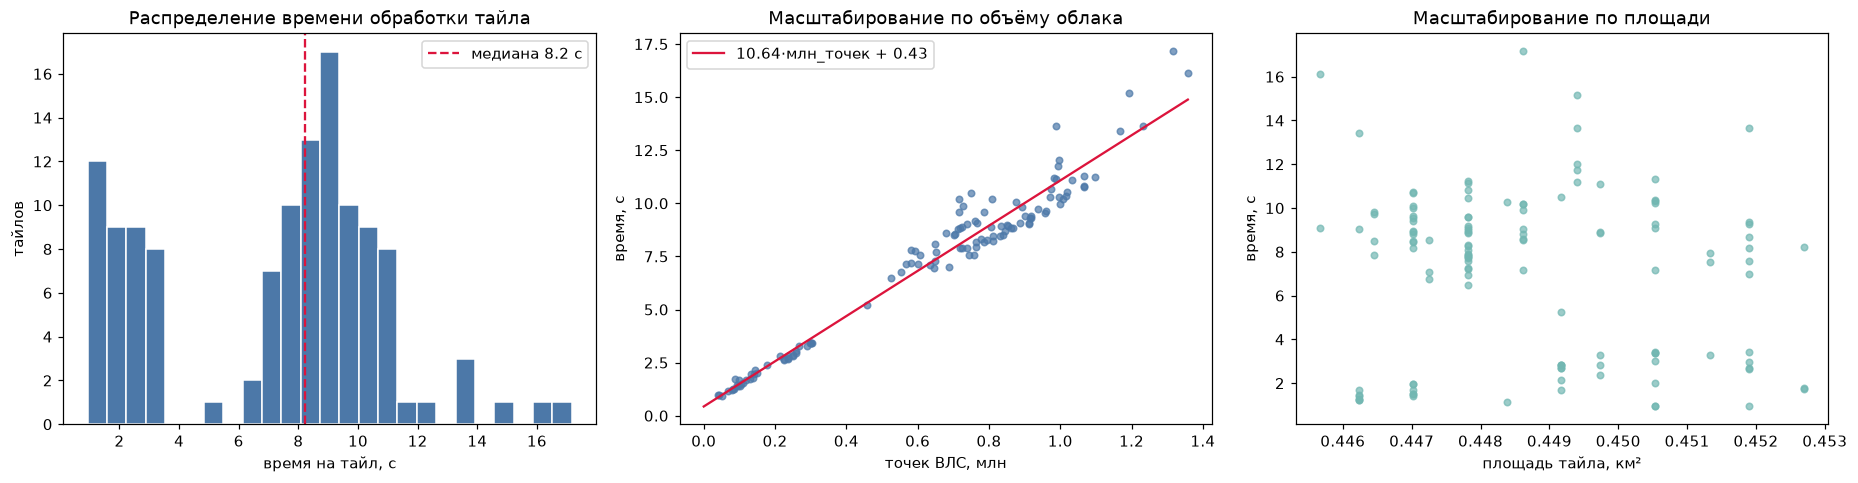

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(t, bins=25, color='#4C78A8', edgecolor='white')
axes[0].axvline(t.median(), color='crimson', ls='--', label=f'медиана {t.median():.1f} с')
axes[0].set_xlabel('время на тайл, с'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Распределение времени обработки тайла'); axes[0].legend()

axes[1].scatter(df['points'] / 1e6, t, s=18, alpha=.7, color='#4C78A8')
k = np.polyfit(df['points'] / 1e6, t, 1)
xs = np.linspace(0, (df['points'] / 1e6).max(), 50)
axes[1].plot(xs, np.polyval(k, xs), color='crimson', lw=1.5,
             label=f'{k[0]:.2f}·млн_точек + {k[1]:.2f}')
axes[1].set_xlabel('точек ВЛС, млн'); axes[1].set_ylabel('время, с')
axes[1].set_title('Масштабирование по объёму облака'); axes[1].legend()

axes[2].scatter(df['area_km2'], t, s=18, alpha=.7, color='#72B7B2')
axes[2].set_xlabel('площадь тайла, км²'); axes[2].set_ylabel('время, с')
axes[2].set_title('Масштабирование по площади')

plt.tight_layout(); plt.show()

## 6. Время по шагам конвейера

In [8]:
step_cols = [f'ms_{s}' for s in RB.STEP_ORDER]
steps = df[step_cols].rename(columns=lambda c: c[3:])

step_summary = pd.DataFrame({
    'сумма, с': steps.sum() / 1000,
    'доля, %': 100 * steps.sum() / steps.sum().sum(),
    'медиана, мс': steps.median(),
    'среднее, мс': steps.mean(),
    'p95, мс': steps.quantile(.95),
    'max, мс': steps.max(),
}).sort_values('доля, %', ascending=False).round(2)
step_summary

,"сумма, с","доля, %","медиана, мс","среднее, мс","p95, мс","max, мс"
dtm,439.76,49.97,4097.0,3575.24,5881.9,8833
dsm,374.84,42.60,3496.0,3047.45,5229.0,7620
tin,14.87,1.69,109.0,120.86,256.9,285
heights,11.84,1.35,88.0,96.23,195.9,215
contours,9.32,1.06,54.0,75.75,164.8,1058
tpi,8.92,1.01,74.0,72.50,84.8,97
aspect,8.57,0.97,72.0,69.72,81.0,99
slope,8.36,0.95,70.0,67.98,77.0,95
smooth,3.53,0.40,30.0,28.70,34.9,40
crop,0.00,0.00,0.0,0.00,0.0,0


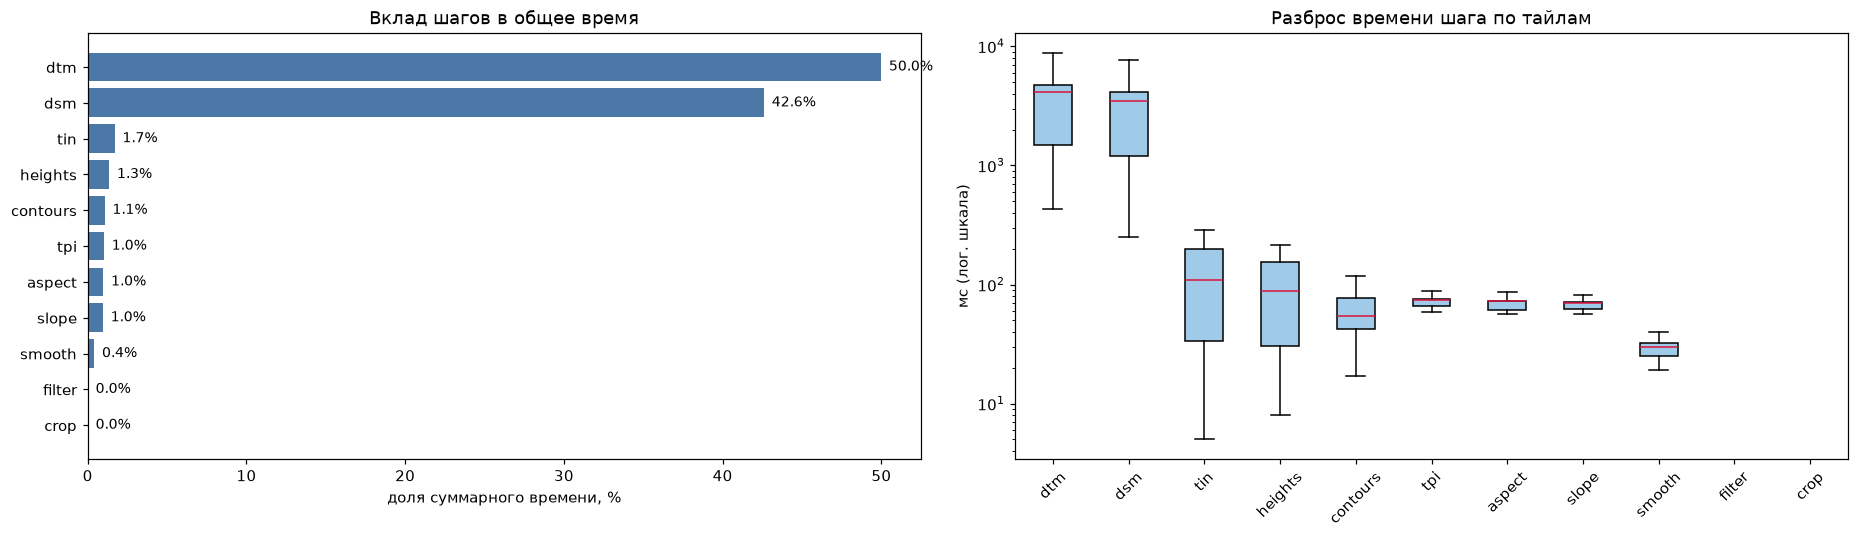

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

share = (steps.sum() / steps.sum().sum() * 100).sort_values()
axes[0].barh(share.index, share.values, color='#4C78A8')
for i, v in enumerate(share.values):
    axes[0].text(v + .5, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('доля суммарного времени, %')
axes[0].set_title('Вклад шагов в общее время')

order = share.index[::-1]
axes[1].boxplot([steps[c].dropna() for c in order], tick_labels=list(order),
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#A0CBE8'), medianprops=dict(color='crimson'))
axes[1].set_yscale('log'); axes[1].set_ylabel('мс (лог. шкала)')
axes[1].set_title('Разброс времени шага по тайлам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

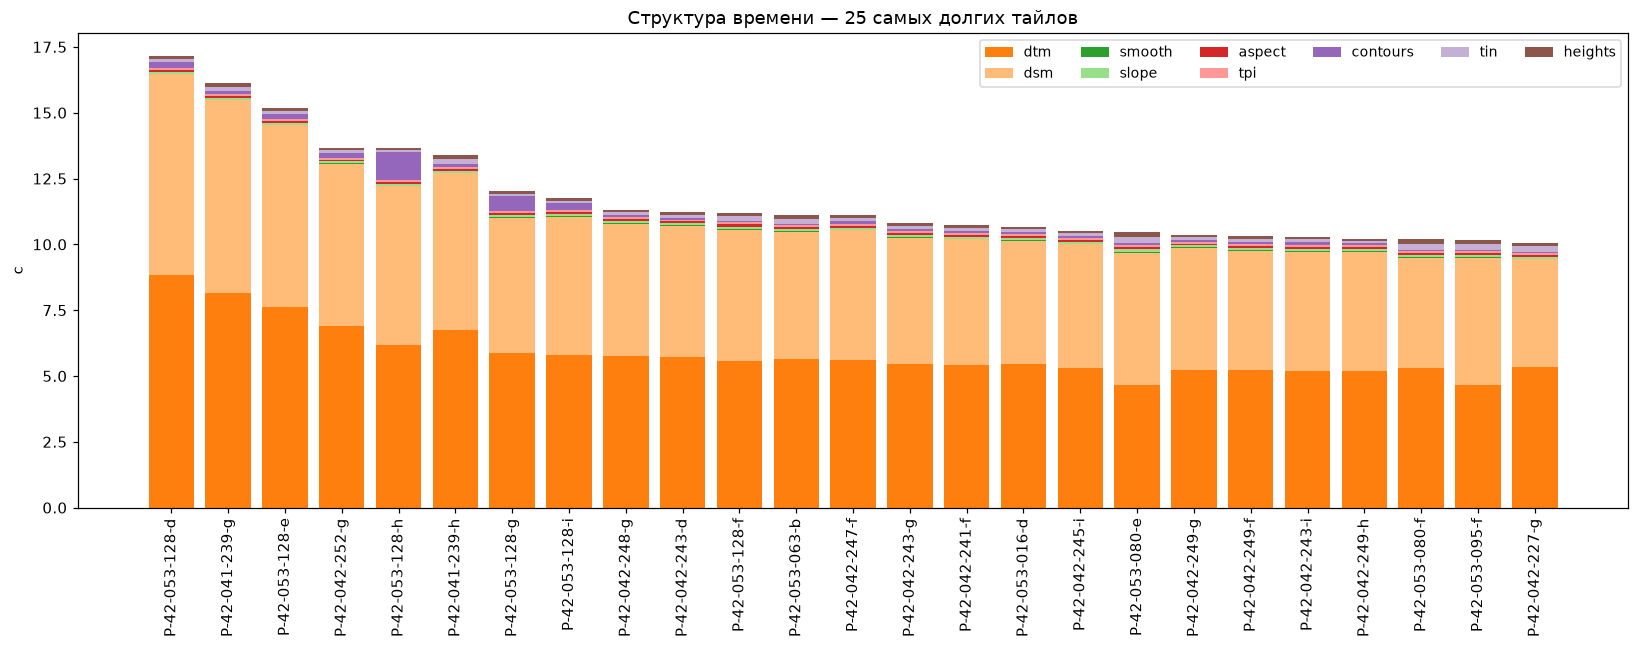

In [10]:
# Стек по 25 самым тяжёлым тайлам
top = df.nlargest(25, 'tile_s')
sub = top[step_cols].rename(columns=lambda c: c[3:]).fillna(0) / 1000

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(sub))
cmap = plt.get_cmap('tab20')
for i, c in enumerate(RB.STEP_ORDER):
    if c in sub and sub[c].sum() > 0:
        ax.bar(sub.index, sub[c], bottom=bottom, label=c, color=cmap(i % 20))
        bottom += sub[c].values
ax.set_ylabel('с'); ax.set_title('Структура времени — 25 самых долгих тайлов')
ax.tick_params(axis='x', rotation=90)
ax.legend(ncol=6, fontsize=9)
plt.tight_layout(); plt.show()

## 7. Время и размер по каждому выходному результату

Каждый артефакт привязан к породившему его шагу. `dtm` и `ground_las` выходят из
одного шага `dtm`; четыре шейпфайла горизонталей — из одного шага `contours`
(посечённая разбивка — в п. 7.1).

In [11]:
rows = []
for r in ok:
    for a in r.get('artifacts', []):
        rows.append({'tile': r['name'], 'layer': a['layer'], 'kind': a['kind'],
                     'file': a['file'], 'step': a['step'],
                     'ms': a['step_ms'], 'size_kb': (a['size_bytes'] or 0) / 1024})
arts = pd.DataFrame(rows)

# Размеры считаются по файлам, время — по уникальным парам (тайл, шаг):
# шаг `dtm` отдаёт два артефакта, `contours` — четыре, и наивное суммирование
# по файлам умножило бы их время на число файлов.
size_agg = arts.groupby('layer').agg(
    файлов=('file', 'count'),
    формат=('kind', 'first'),
    шаг=('step', 'first'),
    медиана_KB=('size_kb', 'median'),
    сумма_MB=('size_kb', lambda s: s.sum() / 1024),
)
time_agg = (arts.drop_duplicates(subset=['tile', 'step'])
            .groupby('step')['ms']
            .agg(медиана_мс='median', среднее_мс='mean',
                 p95_мс=lambda s: s.quantile(.95),
                 сумма_с=lambda s: s.sum() / 1000))

by_layer = (size_agg.join(time_agg, on='шаг')
            .sort_values('сумма_с', ascending=False).round(2))
by_layer['примечание'] = np.where(
    by_layer.groupby('шаг')['шаг'].transform('size') > 1,
    'время делится с др. слоями того же шага', '')
by_layer

,файлов,формат,шаг,медиана_KB,сумма_MB,медиана_мс,среднее_мс,p95_мс,сумма_с,примечание
layer,,,,,,,,,,
dtm,123,geotiff,dtm,1745.34,160.70,4097.0,3575.24,5881.9,439.76,время делится с др. слоями того же шага
ground_las,123,las,dtm,25420.32,2668.49,4097.0,3575.24,5881.9,439.76,время делится с др. слоями того же шага
dsm,123,geotiff,dsm,1750.64,161.36,3496.0,3047.45,5229.0,374.84,
tin,123,dxf,tin,3076.79,416.86,109.0,120.86,256.9,14.87,
heights,123,shp,heights,313.69,42.59,88.0,96.23,195.9,11.84,
contours,492,shp,contours,228.92,387.75,54.0,75.75,164.8,9.32,
tpi,123,geotiff,tpi,18.67,1.76,74.0,72.50,84.8,8.92,
aspect,123,geotiff,aspect,1745.34,160.70,72.0,69.72,81.0,8.57,
slope,123,geotiff,slope,1745.34,160.70,70.0,67.98,77.0,8.36,


### 7.2. Самые крупные артефакты

`ground_las` (LAS отфильтрованных ground-точек) — крупнейший по объёму выход:
он сохраняется как промежуточный вход для TIN и отметок высот. Если он не нужен
потребителю, `save_ground_las=False` в `step_dtm` убирает ~2.6 ГБ на 123 тайлах
без влияния на остальные артефакты.

In [12]:
tot = by_layer['сумма_MB'].sum()
disk = by_layer[['формат', 'файлов', 'медиана_KB', 'сумма_MB']].copy()
disk['доля объёма, %'] = (100 * disk['сумма_MB'] / tot).round(1)
display(disk.sort_values('сумма_MB', ascending=False).round(2))
print(f'Итого артефактов: {int(disk["файлов"].sum())} файлов, {tot/1024:.2f} ГБ '
      f'на {len(df)} тайлов ({tot/len(df):.0f} МБ на тайл)')

,формат,файлов,медиана_KB,сумма_MB,"доля объёма, %"
layer,,,,,
ground_las,las,123,25420.32,2668.49,61.8
tin,dxf,123,3076.79,416.86,9.6
contours,shp,492,228.92,387.75,9.0
dsm,geotiff,123,1750.64,161.36,3.7
dtm,geotiff,123,1745.34,160.70,3.7
aspect,geotiff,123,1745.34,160.70,3.7
slope,geotiff,123,1745.34,160.70,3.7
dtm_smooth,geotiff,123,1743.11,160.48,3.7
heights,shp,123,313.69,42.59,1.0


Итого артефактов: 1599 файлов, 4.22 ГБ на 123 тайлов (35 МБ на тайл)


### 7.1. Горизонтали посечённо

In [13]:
crows = []
for r in ok:
    for interval, v in (r.get('contours_detail') or {}).items():
        crows.append({'tile': r['name'], 'сечение_м': float(interval),
                      'ms': v['ms'], 'size_kb': (v['size_bytes'] or 0) / 1024})
cdf = pd.DataFrame(crows)
if len(cdf):
    display(cdf.groupby('сечение_м').agg(
        тайлов=('tile', 'count'),
        медиана_мс=('ms', 'median'),
        среднее_мс=('ms', 'mean'),
        p95_мс=('ms', lambda s: s.quantile(.95)),
        медиана_KB=('size_kb', 'median'),
    ).round(2))
else:
    print('Посечённые замеры отсутствуют в результатах')

,тайлов,медиана_мс,среднее_мс,p95_мс,медиана_KB
сечение_м,,,,,
0.5,123,27.00,43.88,97.95,1189.90
2.0,123,12.78,16.72,30.21,335.39
5.0,123,7.53,10.61,25.76,46.32
10.0,123,5.17,7.25,15.68,0.10


## 8. Накладные расходы вне сервиса

`assess` — оценка материалов ВЛС/АФС (Q3 «Оценка файлов»), входит в
production-путь. `restore` — восстановление абсолютных Z из ТЛО, **артефакт
методологии бенчмарка**, в production его не будет. `metrics` — расчёт метрик
точности, только для бенчмарка.

In [14]:
overhead = df[['assess_ms', 'restore_ms', 'metrics_ms']].rename(columns={
    'assess_ms': 'оценка материалов', 'restore_ms': 'восстановление Z (ТЛО→абс.)',
    'metrics_ms': 'расчёт метрик точности'})
pd.DataFrame({
    'медиана, мс': overhead.median(),
    'среднее, мс': overhead.mean(),
    'сумма, с': overhead.sum() / 1000,
    'к времени конвейера, %': 100 * overhead.sum() / df['tile_s'].sum() / 1000,
}).round(2)

,"медиана, мс","среднее, мс","сумма, с","к времени конвейера, %"
оценка материалов,33.33,36.05,4.43,0.50
восстановление Z (ТЛО→абс.),70.46,63.87,7.86,0.89
расчёт метрик точности,294.95,276.04,33.95,3.86


---
# ЧАСТЬ II. ТОЧНОСТЬ

## 9. ЦМР против эталона

Отклонение `Δ = ЦМР_построенная − ЦМР_эталон` по совпадающим ячейкам
(построенный растр перепроецирован на сетку эталона, билинейно).

* **ME** — систематический сдвиг (bias)
* **MAE / RMSE** — средняя и среднеквадратичная ошибка
* **NMAD** = `1.4826 · median(|Δ − median Δ|)` — робастная σ, устойчива к выбросам
* **P95** — 95-й перцентиль |Δ|
* **coverage** — доля ячеек эталона, покрытых построенной ЦМР

In [15]:
def acc_frame(layer):
    rows = []
    for r in ok:
        a = (r.get('accuracy') or {}).get(layer)
        if a:
            rows.append({'tile': r['name'], **a})
    return pd.DataFrame(rows).set_index('tile') if rows else pd.DataFrame()

acc_dtm = acc_frame('dtm')
acc_smooth = acc_frame('dtm_smooth')
acc_dsm = acc_frame('dsm')

metrics = ['me', 'mae', 'rmse', 'nmad', 'p68', 'p95', 'max_abs', 'coverage_pct', 'rel_rmse_pct']
summary_acc = pd.DataFrame({
    'ЦМР (сырая)': acc_dtm[metrics].median(),
    'ЦМР (сглаж., σ=2)': acc_smooth[metrics].median(),
}).T
summary_acc.columns = ['ME, м', 'MAE, м', 'RMSE, м', 'NMAD, м', 'P68, м', 'P95, м',
                       'max|Δ|, м', 'покрытие, %', 'отн. RMSE, %']
print('Медиана по', len(acc_dtm), 'тайлам:')
display(summary_acc.round(4))

d = acc_dtm['rmse']
display(pd.DataFrame({'RMSE ЦМР, м': [d.min(), d.quantile(.25), d.median(), d.mean(),
                                      d.quantile(.75), d.quantile(.95), d.max()]},
                     index=['min', 'p25', 'median', 'mean', 'p75', 'p95', 'max']).round(4))

Медиана по 123 тайлам:


,"ME, м","MAE, м","RMSE, м","NMAD, м","P68, м","P95, м","max|Δ|, м","покрытие, %","отн. RMSE, %"
ЦМР (сырая),0.0095,0.071,0.0990,0.0763,0.0859,0.2052,0.7747,87.6908,0.0891
"ЦМР (сглаж., σ=2)",0.0073,0.088,0.1195,0.1020,0.1011,0.2316,1.1424,87.6908,0.1036


,"RMSE ЦМР, м"
min,0.0516
p25,0.0672
median,0.0990
mean,0.0940
p75,0.1177
p95,0.1329
max,0.1404


In [16]:
crit = 5.0  # критерий проекта: отн. RMSE < 5 %
passed = (acc_dtm['rel_rmse_pct'] < crit).sum()
print(f'Критерий «отн. RMSE < {crit} %»: {passed}/{len(acc_dtm)} тайлов '
      f'({100*passed/len(acc_dtm):.1f} %) — '
      f'{"✓ ПРОЙДЕН" if passed == len(acc_dtm) else "✗ есть исключения"}')
print(f'Максимальная относительная ошибка по датасету: '
      f'{acc_dtm["rel_rmse_pct"].max():.4f} %')
print(f'Худшие тайлы по RMSE:')
display(acc_dtm.nlargest(5, 'rmse')[['rmse', 'mae', 'me', 'nmad', 'p95',
                                     'coverage_pct', 'rel_rmse_pct']].round(4))

Критерий «отн. RMSE < 5.0 %»: 123/123 тайлов (100.0 %) — ✓ ПРОЙДЕН
Максимальная относительная ошибка по датасету: 0.1400 %
Худшие тайлы по RMSE:


,rmse,mae,me,nmad,p95,coverage_pct,rel_rmse_pct
tile,,,,,,,
P-42-042-247-c,0.1404,0.0985,0.0355,0.1037,0.2959,68.6422,0.1220
P-42-042-246-b,0.1378,0.0979,0.0396,0.1041,0.2921,80.3000,0.1209
P-42-042-248-b,0.1364,0.0971,0.0372,0.1041,0.2893,79.6456,0.1170
P-42-053-015-b,0.1362,0.0970,0.0330,0.1037,0.2873,79.2503,0.1246
P-42-042-253-d,0.1349,0.0960,0.0230,0.1026,0.2846,79.5538,0.1167


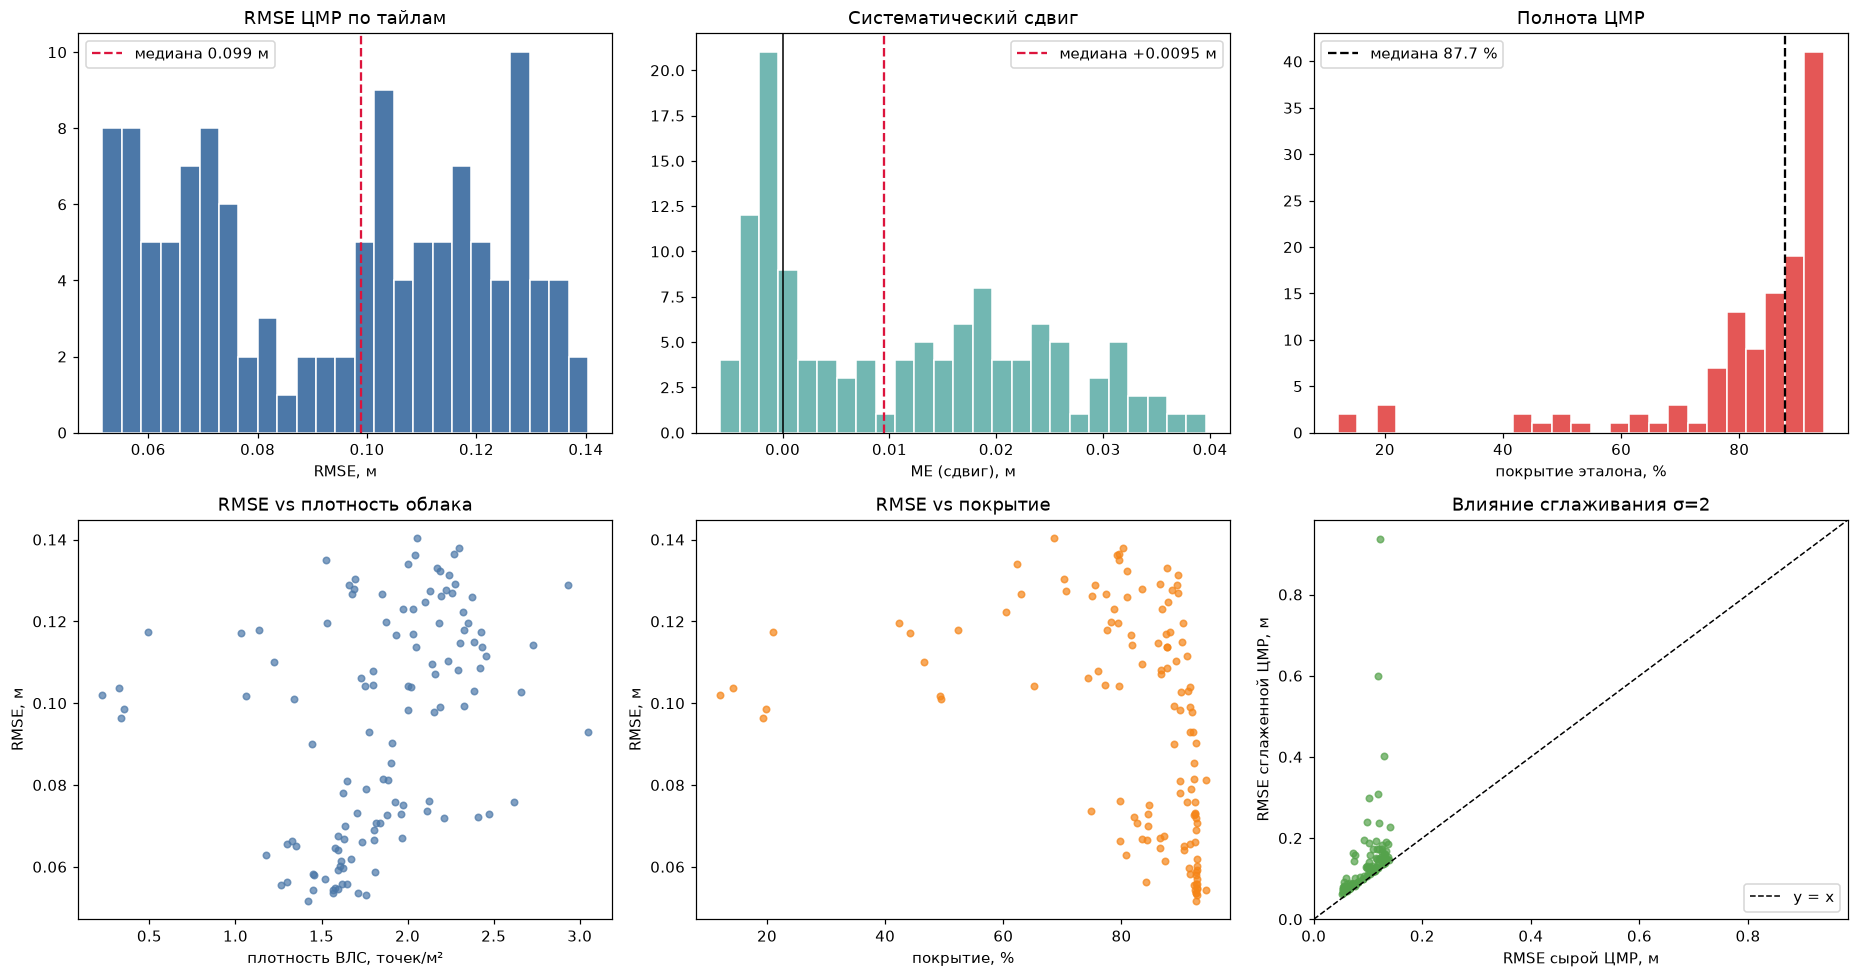

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

axes[0, 0].hist(acc_dtm['rmse'], bins=25, color='#4C78A8', edgecolor='white')
axes[0, 0].axvline(acc_dtm['rmse'].median(), color='crimson', ls='--',
                   label=f"медиана {acc_dtm['rmse'].median():.3f} м")
axes[0, 0].set_xlabel('RMSE, м'); axes[0, 0].set_title('RMSE ЦМР по тайлам'); axes[0, 0].legend()

axes[0, 1].hist(acc_dtm['me'], bins=25, color='#72B7B2', edgecolor='white')
axes[0, 1].axvline(0, color='k', lw=1)
axes[0, 1].axvline(acc_dtm['me'].median(), color='crimson', ls='--',
                   label=f"медиана {acc_dtm['me'].median():+.4f} м")
axes[0, 1].set_xlabel('ME (сдвиг), м'); axes[0, 1].set_title('Систематический сдвиг'); axes[0, 1].legend()

axes[0, 2].hist(acc_dtm['coverage_pct'], bins=25, color='#E45756', edgecolor='white')
axes[0, 2].axvline(acc_dtm['coverage_pct'].median(), color='k', ls='--',
                   label=f"медиана {acc_dtm['coverage_pct'].median():.1f} %")
axes[0, 2].set_xlabel('покрытие эталона, %'); axes[0, 2].set_title('Полнота ЦМР'); axes[0, 2].legend()

axes[1, 0].scatter(df.loc[acc_dtm.index, 'density_pts_m2'], acc_dtm['rmse'],
                   s=18, alpha=.7, color='#4C78A8')
axes[1, 0].set_xlabel('плотность ВЛС, точек/м²'); axes[1, 0].set_ylabel('RMSE, м')
axes[1, 0].set_title('RMSE vs плотность облака')

axes[1, 1].scatter(acc_dtm['coverage_pct'], acc_dtm['rmse'], s=18, alpha=.7, color='#F58518')
axes[1, 1].set_xlabel('покрытие, %'); axes[1, 1].set_ylabel('RMSE, м')
axes[1, 1].set_title('RMSE vs покрытие')

axes[1, 2].scatter(acc_dtm['rmse'], acc_smooth.loc[acc_dtm.index, 'rmse'],
                   s=18, alpha=.7, color='#54A24B')
lim = [0, max(acc_dtm['rmse'].max(), acc_smooth['rmse'].max()) * 1.05]
axes[1, 2].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[1, 2].set_xlim(lim); axes[1, 2].set_ylim(lim)
axes[1, 2].set_xlabel('RMSE сырой ЦМР, м'); axes[1, 2].set_ylabel('RMSE сглаженной ЦМР, м')
axes[1, 2].set_title('Влияние сглаживания σ=2'); axes[1, 2].legend()

plt.tight_layout(); plt.show()

### 9.1. Покрытие — узкое место

RMSE стабилен, а вот **полнота** ЦМР гуляет от 12 % до 95 % площади эталона.
Причин ровно две, и `max_search_distance` к ним отношения не имеет:

1. **Топологический гейт в `GroundProcessing._interpolate`.** Там
   `holes = binary_fill_holes(valid) & ~valid`, то есть «дырой» считается только
   та область nodata, которая целиком окружена данными. Всё, что касается рамки
   растра, отбрасывается — независимо от того, есть ли рядом реальные точки.
   `fillnodata` при этом уже посчитала значения для всей площади, но
   `np.where(holes, arr_filled, arr)` их выбрасывает. На тайле
   `P-42-042-249-a` так теряется 76 % растра.
2. **Экстент растра меньше листа.** `writers.gdal` строит растр по bbox облака
   ground-точек. У того же `P-42-042-249-a` облако покрывает лишь 22 % площади
   номенклатурного листа — там просто нет ВЛС, и интерполяцией это не лечится.

Важно: RMSE считается только по покрытым ячейкам, поэтому низкое покрытие
**не ухудшает** RMSE — оно просто выводит часть площади из-под оценки.

,"Покрытие эталона, %"
min,12.1
p05,44.5
p25,79.6
median,87.7
p75,91.9
max,94.3


Тайлов с покрытием < 50 %: 10 из 123
Тайлов с покрытием < 70 %: 16 из 123

Худшие по покрытию:


,coverage_pct,плотность_ВЛС,точек,rmse,n_valid,n_ref_valid
tile,,,,,,
P-42-042-247-g,12.073,0.227,98678,0.102,54231,449175
P-42-042-247-h,14.251,0.323,143145,0.104,64013,449175
P-42-042-249-a,19.366,0.337,39637,0.096,22978,118650
P-42-042-249-b,19.756,0.354,41841,0.099,23657,119748
P-42-042-247-d,21.057,0.492,213296,0.118,94584,449175
P-42-042-248-a,42.355,1.532,177602,0.120,48643,114846
P-42-042-247-e,44.227,1.031,457940,0.117,198655,449175
P-42-042-249-c,46.613,1.223,149182,0.110,56308,120798


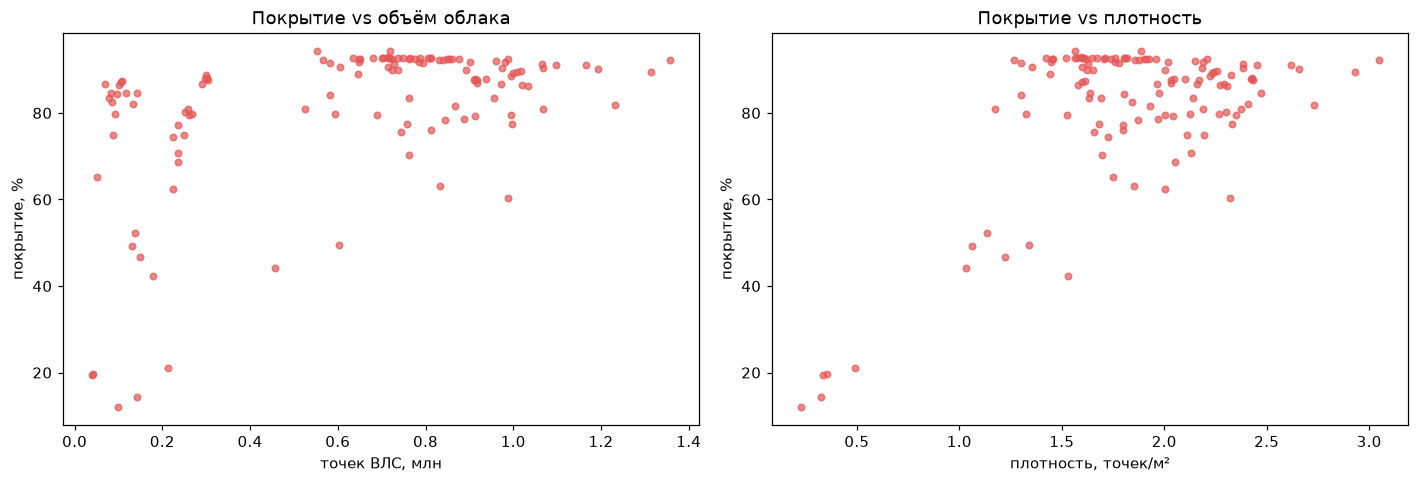

In [18]:
cov = acc_dtm['coverage_pct']
display(pd.DataFrame({'Покрытие эталона, %': [cov.min(), cov.quantile(.05), cov.quantile(.25),
                                              cov.median(), cov.quantile(.75), cov.max()]},
                     index=['min', 'p05', 'p25', 'median', 'p75', 'max']).round(1))
print(f'Тайлов с покрытием < 50 %: {(cov < 50).sum()} из {len(cov)}')
print(f'Тайлов с покрытием < 70 %: {(cov < 70).sum()} из {len(cov)}')
print('\nХудшие по покрытию:')
worst = acc_dtm.nsmallest(8, 'coverage_pct')[['coverage_pct', 'rmse', 'n_valid', 'n_ref_valid']]
worst.insert(1, 'плотность_ВЛС', df.loc[worst.index, 'density_pts_m2'])
worst.insert(2, 'точек', df.loc[worst.index, 'points'])
display(worst.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(df.loc[acc_dtm.index, 'points'] / 1e6, cov, s=18, alpha=.7, color='#E45756')
ax[0].set_xlabel('точек ВЛС, млн'); ax[0].set_ylabel('покрытие, %')
ax[0].set_title('Покрытие vs объём облака')
ax[1].scatter(df.loc[acc_dtm.index, 'density_pts_m2'], cov, s=18, alpha=.7, color='#E45756')
ax[1].set_xlabel('плотность, точек/м²'); ax[1].set_ylabel('покрытие, %')
ax[1].set_title('Покрытие vs плотность')
plt.tight_layout(); plt.show()

### 9.2. Влияние сглаживания

Сглаживание Гауссом (σ = 2 × res) — обязательный шаг перед расчётом производных
(уклон/экспозиция считаются по сглаженному растру, `resolve_base_raster`).
Оно подавляет шум растеризации, но одновременно срезает реальные детали рельефа,
поэтому относительно эталона RMSE закономерно растёт.

In [19]:
cmp_sm = pd.DataFrame({
    'сырая ЦМР': acc_dtm[['rmse', 'mae', 'nmad', 'p95', 'max_abs', 'z_std']].median(),
    'сглаженная ЦМР': acc_smooth[['rmse', 'mae', 'nmad', 'p95', 'max_abs', 'z_std']].median(),
})
cmp_sm['изменение, %'] = 100 * (cmp_sm['сглаженная ЦМР'] / cmp_sm['сырая ЦМР'] - 1)
cmp_sm.index = ['RMSE, м', 'MAE, м', 'NMAD, м', 'P95, м', 'max|Δ|, м', 'σ высот растра, м']
cmp_sm.round(4)

,сырая ЦМР,сглаженная ЦМР,"изменение, %"
"RMSE, м",0.0990,0.1195,20.7321
"MAE, м",0.0710,0.0880,23.9181
"NMAD, м",0.0763,0.1020,33.7695
"P95, м",0.2052,0.2316,12.8267
"max|Δ|, м",0.7747,1.1424,47.4659
"σ высот растра, м",0.4671,0.4481,-4.0755


## 10. ЦММ (DSM)

Эталона для ЦММ в датасете нет — ЦММ строится по всем точкам (`output_type='max'`),
эталон же представляет землю. Поэтому «ошибка ЦММ относительно эталона» —
это не ошибка, а **высота растительности и объектов над землёй**; она приводится
как описательная величина. Содержательный показатель — `ЦММ − ЦМР`.

In [20]:
hrows = []
for r in ok:
    h = (r.get('accuracy') or {}).get('dsm_minus_dtm')
    if h:
        hrows.append({'tile': r['name'], **h})
hdf = pd.DataFrame(hrows).set_index('tile')

display(pd.DataFrame({
    'ЦММ − ЦМР (высота объектов), м': [hdf['mean'].median(), hdf['p95'].median(), hdf['max'].median(),
                                       hdf['max'].max()],
    'ЦММ vs эталон (для справки), м': [acc_dsm['me'].median(), acc_dsm['p95'].median(),
                                       acc_dsm['max_abs'].median(), acc_dsm['max_abs'].max()],
}, index=['медиана среднего', 'медиана P95', 'медиана max', 'глобальный max']).round(3))

display(pd.DataFrame({
    'ЦММ': acc_dsm[['z_min', 'z_max', 'z_mean', 'z_std', 'valid_pct', 'coverage_pct']].median(),
    'ЦМР': acc_dtm[['z_min', 'z_max', 'z_mean', 'z_std', 'valid_pct', 'coverage_pct']].median(),
}).round(3))

,"ЦММ − ЦМР (высота объектов), м","ЦММ vs эталон (для справки), м"
медиана среднего,0.862,0.895
медиана P95,2.164,2.134
медиана max,13.299,13.391
глобальный max,27.488,27.364


,ЦММ,ЦМР
z_min,111.480,111.720
z_max,124.360,115.290
z_mean,114.895,113.362
z_std,1.172,0.467
valid_pct,91.718,87.624
coverage_pct,91.922,87.691


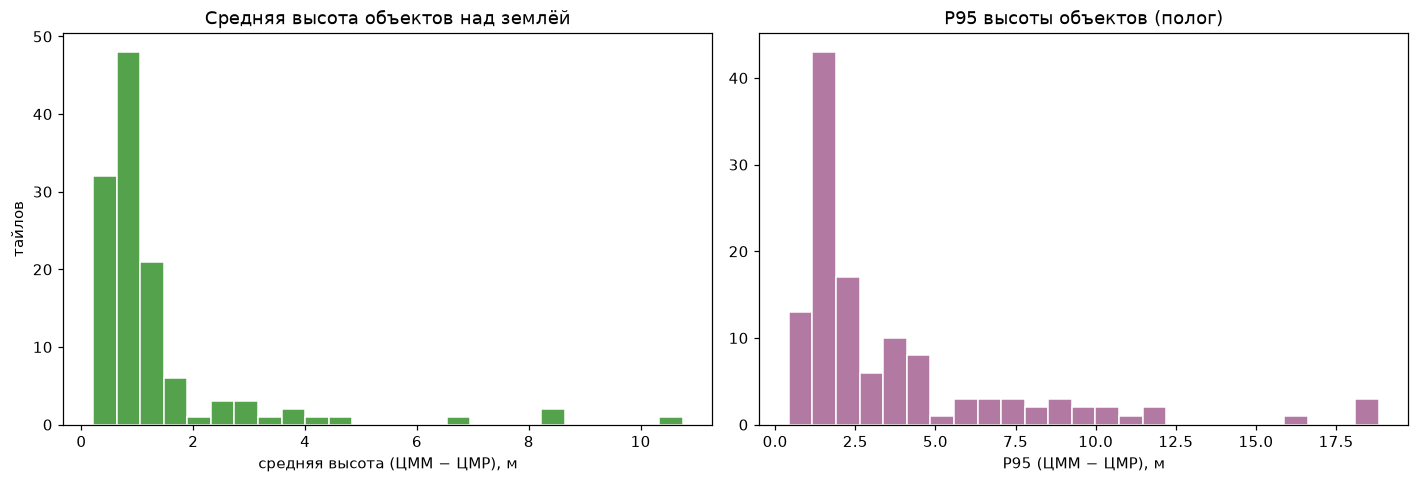

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(hdf['mean'], bins=25, color='#54A24B', edgecolor='white')
axes[0].set_xlabel('средняя высота (ЦММ − ЦМР), м'); axes[0].set_ylabel('тайлов')
axes[0].set_title('Средняя высота объектов над землёй')
axes[1].hist(hdf['p95'], bins=25, color='#B279A2', edgecolor='white')
axes[1].set_xlabel('P95 (ЦММ − ЦМР), м')
axes[1].set_title('P95 высоты объектов (полог)')
plt.tight_layout(); plt.show()

## 11. Визуальный контроль на одном тайле

Живой прогон одного триплета с сохранением артефактов — чтобы убедиться, что
цифры выше соответствуют осмысленным растрам.

In [22]:
import rasterio, tempfile, shutil

DEMO_TILE = acc_dtm['rmse'].sort_values().index[len(acc_dtm) // 2]  # медианный по RMSE
tri = next(t for t in triplets if t.name == DEMO_TILE)
demo_dir = tempfile.mkdtemp(prefix='relief_bench_demo_')
rec = RB.run_triplet(tri, demo_dir, keep_outputs=True)
art = {a['layer']: a['path'] for a in rec['artifacts']}
print(f"Тайл {DEMO_TILE}: {rec['status']}, {rec['tile_duration_ms']} мс, "
      f"RMSE={rec['accuracy']['dtm']['rmse']:.3f} м")

ERROR 1: TIFFFetchDirectory:Sanity check on directory count failed, this is probably not a valid IFD offset
ERROR 1: TIFFReadDirectory:Failed to read directory at offset 1789034
ERROR 1: TIFFFetchDirectory:Sanity check on directory count failed, this is probably not a valid IFD offset
ERROR 1: TIFFReadDirectory:Failed to read directory at offset 1789034


Тайл P-42-053-128-f: done, 11015 мс, RMSE=0.099 м


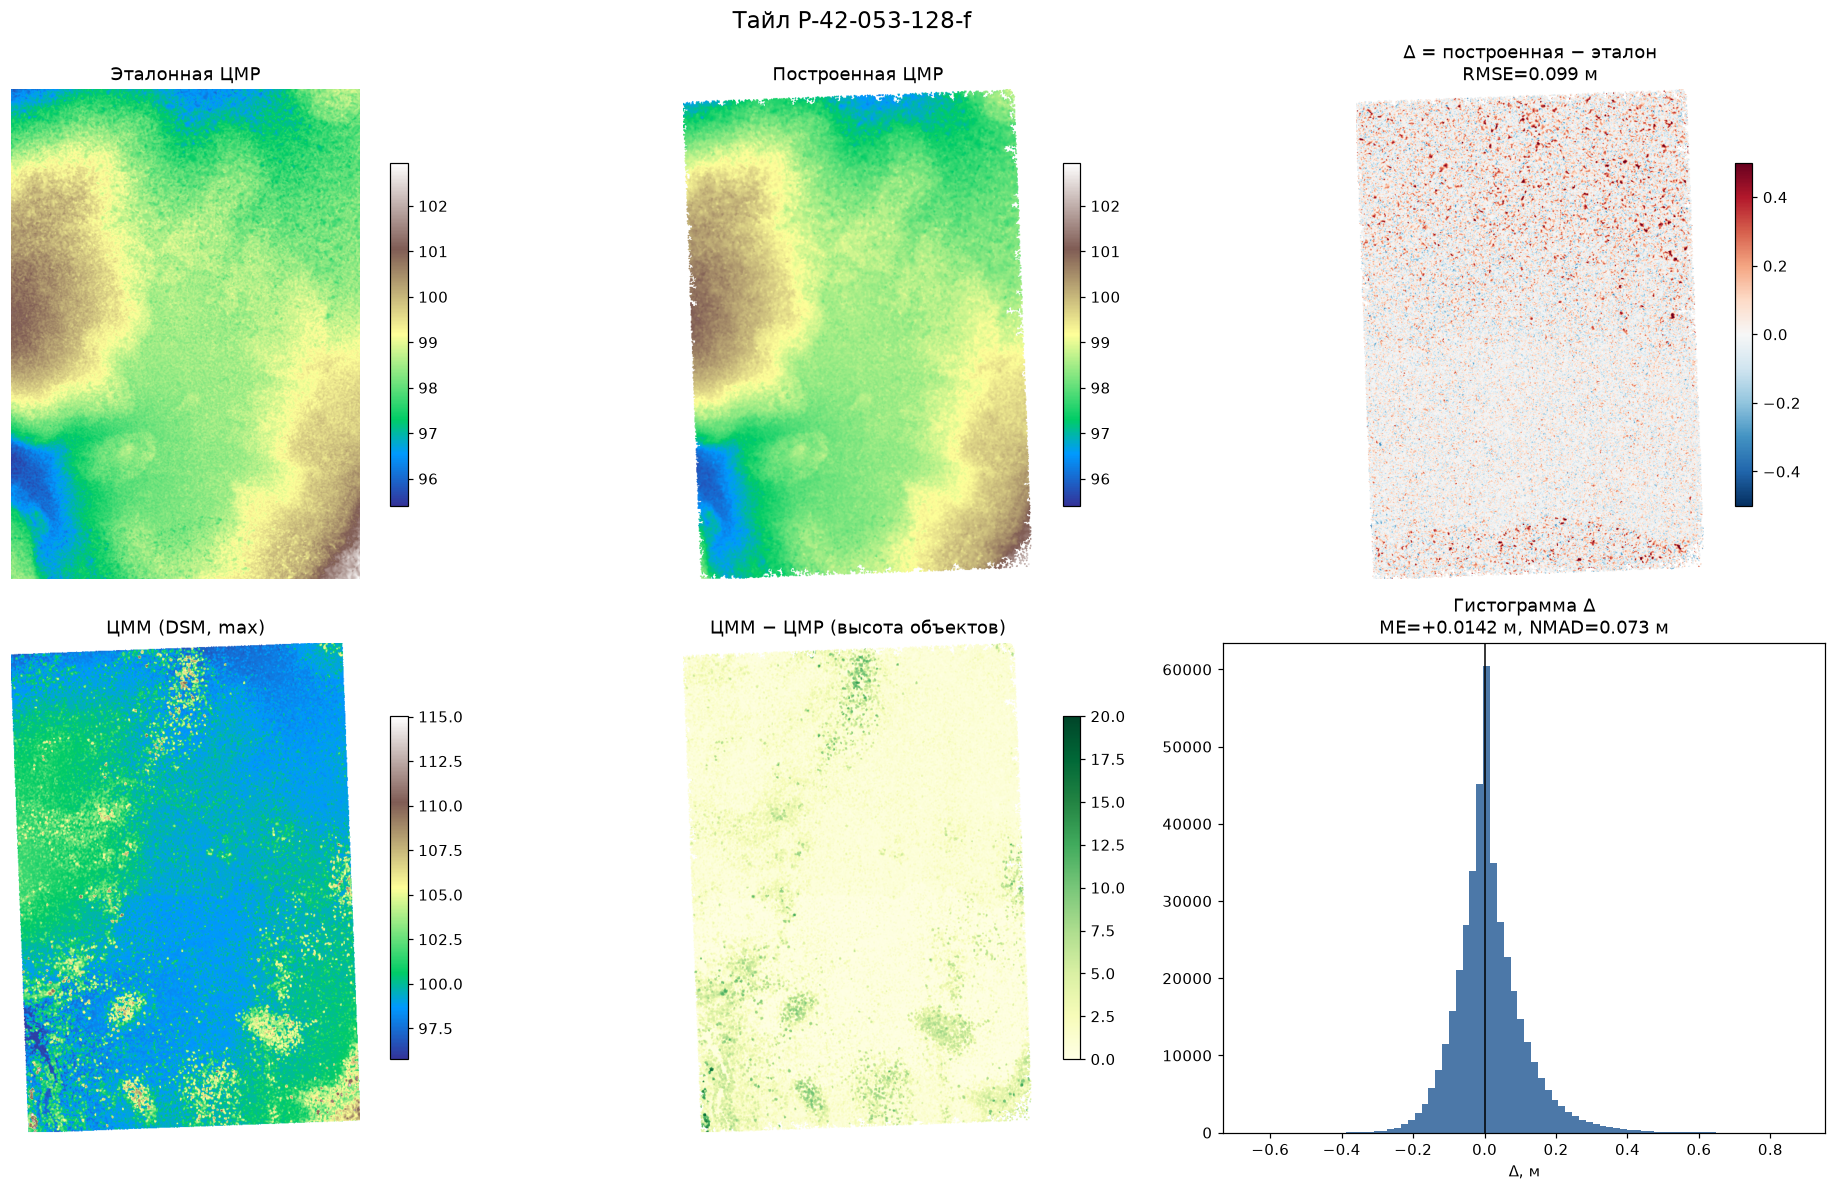

In [23]:
def read_raster(p):
    with rasterio.open(p) as s:
        a = s.read(1).astype(float)
        if s.nodata is not None:
            a = np.where(a == s.nodata, np.nan, a)
    return a

built, ref = RB.align_to_reference(art['dtm'], tri.ref)
diff = built - ref
dsm_a = RB.align_to_reference(art['dsm'], tri.ref)[0]

norm = mcolors.Normalize(vmin=np.nanmin(ref), vmax=np.nanmax(ref))
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, arr, title, kw in [
    (axes[0, 0], ref, 'Эталонная ЦМР', dict(cmap='terrain', norm=norm)),
    (axes[0, 1], built, 'Построенная ЦМР', dict(cmap='terrain', norm=norm)),
    (axes[0, 2], diff, f'Δ = построенная − эталон\nRMSE={np.sqrt(np.nanmean(diff**2)):.3f} м',
     dict(cmap='RdBu_r', vmin=-0.5, vmax=0.5)),
    (axes[1, 0], dsm_a, 'ЦММ (DSM, max)', dict(cmap='terrain')),
    (axes[1, 1], dsm_a - built, 'ЦММ − ЦМР (высота объектов)', dict(cmap='YlGn', vmin=0, vmax=20)),
]:
    im = ax.imshow(arr, **kw); ax.set_title(title, fontsize=12); ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=.7)

v = diff[np.isfinite(diff)]
axes[1, 2].hist(v, bins=80, color='#4C78A8', edgecolor='none')
axes[1, 2].axvline(0, color='k', lw=1)
axes[1, 2].set_title(f'Гистограмма Δ\nME={v.mean():+.4f} м, NMAD='
                     f'{1.4826*np.median(np.abs(v-np.median(v))):.3f} м', fontsize=12)
axes[1, 2].set_xlabel('Δ, м')

plt.suptitle(f'Тайл {DEMO_TILE}', fontsize=15)
plt.tight_layout(); plt.show()

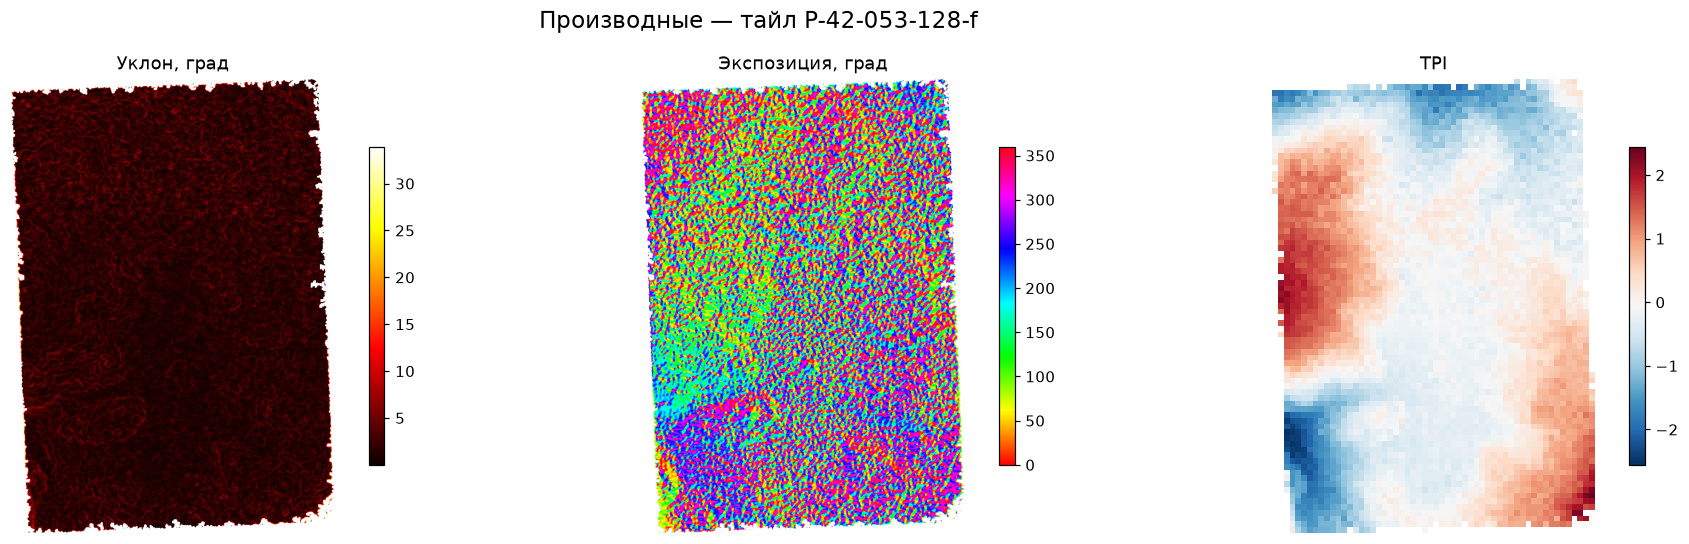

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, layer, title, cmap in [
    (axes[0], 'slope', 'Уклон, град', 'hot'),
    (axes[1], 'aspect', 'Экспозиция, град', 'hsv'),
    (axes[2], 'tpi', 'TPI', 'RdBu_r'),
]:
    if layer in art:
        im = ax.imshow(read_raster(art[layer]), cmap=cmap)
        ax.set_title(title, fontsize=12); ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=.7)
plt.suptitle(f'Производные — тайл {DEMO_TILE}', fontsize=15)
plt.tight_layout(); plt.show()

shutil.rmtree(demo_dir, ignore_errors=True)

## 12. Полная таблица результатов

Экспорт в CSV рядом с `results.jsonl`.

In [25]:
csv_path = RESULTS_DIR / 'benchmark_tiles.csv'
df.to_csv(csv_path, encoding='utf-8')
layer_csv = RESULTS_DIR / 'benchmark_by_layer.csv'
by_layer.to_csv(layer_csv, encoding='utf-8')
print('Сохранено:', csv_path, 'и', layer_csv)
df.round(4)

Сохранено: /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results/benchmark_tiles.csv и /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results/benchmark_by_layer.csv


,points,area_km2,las_MB,ofp_MB,density_pts_m2,tile_s,total_s,rmse_m,mae_m,me_m,nmad_m,p95_m,coverage_%,rel_rmse_%,ms_crop,ms_filter,ms_dtm,ms_dsm,ms_smooth,ms_slope,ms_aspect,ms_tpi,ms_contours,ms_tin,ms_heights,assess_ms,restore_ms,metrics_ms
tile,,,,,,,,,,,,,,,,,,,,,,,,,,,,
P-42-041-239-e,87500,0.4462,3.0,18.9,2.1122,1.709,1.9965,0.0735,0.0527,0.0003,0.0557,0.1541,74.7954,0.0642,0,0,977,482,20,56,56,59,26,14,14,27.4545,20.7375,183.6214
P-42-041-239-f,93220,0.4462,3.2,19.2,2.1272,1.447,1.7075,0.0761,0.0550,0.0001,0.0591,0.1599,79.6671,0.0649,0,0,703,499,20,56,58,59,20,14,14,28.8557,20.8800,176.0083
P-42-041-239-g,1357824,0.4457,46.2,159.0,3.0484,16.135,16.7271,0.0930,0.0651,-0.0042,0.0681,0.1914,92.1172,0.0850,0,0,8160,7308,28,69,70,76,111,173,135,51.6130,114.8546,291.1673
P-42-041-239-h,1166858,0.4462,39.7,167.6,2.6175,13.410,13.9753,0.0759,0.0551,-0.0004,0.0600,0.1572,91.1570,0.0672,0,0,6740,5954,28,70,71,74,113,200,156,46.5901,94.3117,291.7574
P-42-041-240-d,85211,0.4462,2.9,22.3,1.8418,1.264,1.5229,0.0708,0.0512,-0.0010,0.0548,0.1483,82.6070,0.0610,0,0,613,395,19,57,57,59,20,20,19,25.9988,19.9070,175.2559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P-42-053-128-e,1193099,0.4494,40.6,172.8,2.6595,15.174,15.8410,0.1027,0.0730,0.0108,0.0783,0.2136,90.1085,0.1073,0,0,7634,6883,31,69,71,72,173,129,107,60.1954,114.2282,288.7645
P-42-053-128-f,981695,0.4494,33.4,179.2,2.1873,11.194,11.7205,0.0990,0.0692,0.0142,0.0728,0.2052,91.6625,0.1004,0,0,5575,4983,30,71,99,81,66,159,127,45.5332,79.9872,311.7861
P-42-053-128-g,997204,0.4494,33.9,168.0,2.3293,12.028,13.2806,0.1180,0.0803,0.0239,0.0814,0.2477,77.4845,0.1191,0,0,5891,5112,32,70,73,76,566,110,94,50.4431,94.9338,321.4905


---
## 13. Выводы

*(числа в тексте подставляются из ячейки ниже)*

In [26]:
lines = [
    'ПРОИЗВОДИТЕЛЬНОСТЬ',
    f'  Тайлов обработано:        {len(df)} из {len(triplets)} триплетов, '
    f'{len(bad)} с ошибкой',
    f'  Объём:                    {df["points"].sum()/1e6:.1f} млн точек, '
    f'{df["area_km2"].sum():.2f} км², {df["las_MB"].sum()/1024:.2f} ГБ LAS',
    f'  Время на тайл:            медиана {t.median():.2f} с, p95 {t.quantile(.95):.2f} с, '
    f'max {t.max():.2f} с',
    f'  Суммарное время:          {t.sum()/60:.1f} мин',
    f'  Пропускная способность:   {df["points"].sum()/t.sum()/1e6:.2f} млн точек/с, '
    f'{df["area_km2"].sum()/t.sum()*3600:.0f} км²/час (1 поток)',
    f'  Самые дорогие шаги:       ' + ', '.join(
        f'{k} {v:.0f} %' for k, v in
        (100 * steps.sum() / steps.sum().sum()).sort_values(ascending=False).head(3).items()),
    f'  Масштабирование:          линейное по числу точек '
    f'({np.polyfit(df["points"]/1e6, t, 1)[0]:.2f} с на млн точек)',
    '',
    'ТОЧНОСТЬ ЦМР (относительно эталона; см. ограничение методологии)',
    f'  RMSE:                     медиана {acc_dtm["rmse"].median():.3f} м, '
    f'p95 {acc_dtm["rmse"].quantile(.95):.3f} м, max {acc_dtm["rmse"].max():.3f} м',
    f'  MAE / NMAD:               {acc_dtm["mae"].median():.3f} м / '
    f'{acc_dtm["nmad"].median():.3f} м (медианы)',
    f'  Систематический сдвиг ME: {acc_dtm["me"].median():+.4f} м (медиана) — сдвига нет',
    f'  P95 |Δ|:                  {acc_dtm["p95"].median():.3f} м',
    f'  Покрытие эталона:         медиана {acc_dtm["coverage_pct"].median():.1f} %, '
    f'min {acc_dtm["coverage_pct"].min():.1f} %, '
    f'ниже 50 % — {(acc_dtm["coverage_pct"] < 50).sum()} тайлов',
    f'  Критерий отн. RMSE < 5 %: {passed}/{len(acc_dtm)} тайлов, '
    f'фактический максимум {acc_dtm["rel_rmse_pct"].max():.4f} %',
    f'  Сглаживание σ=2:          RMSE {acc_dtm["rmse"].median():.3f} → '
    f'{acc_smooth["rmse"].median():.3f} м '
    f'({100*(acc_smooth["rmse"].median()/acc_dtm["rmse"].median()-1):+.0f} %) — '
    f'плата за подавление шума перед расчётом производных',
    '',
    'ЦММ (эталона нет)',
    f'  ЦММ − ЦМР:                среднее {hdf["mean"].median():.2f} м, '
    f'P95 {hdf["p95"].median():.2f} м, max {hdf["max"].max():.2f} м',
    f'  Покрытие:                 {acc_dsm["coverage_pct"].median():.1f} % '
    f'(выше ЦМР — ЦММ строится по всем точкам, не только ground)',
]
print('\n'.join(lines))

ПРОИЗВОДИТЕЛЬНОСТЬ
  Тайлов обработано:        123 из 123 триплетов, 0 с ошибкой
  Объём:                    77.7 млн точек, 55.19 км², 2.58 ГБ LAS
  Время на тайл:            медиана 8.23 с, p95 12.00 с, max 17.17 с
  Суммарное время:          14.7 мин
  Пропускная способность:   0.09 млн точек/с, 226 км²/час (1 поток)
  Самые дорогие шаги:       dtm 50 %, dsm 43 %, tin 2 %
  Масштабирование:          линейное по числу точек (10.64 с на млн точек)

ТОЧНОСТЬ ЦМР (относительно эталона; см. ограничение методологии)
  RMSE:                     медиана 0.099 м, p95 0.133 м, max 0.140 м
  MAE / NMAD:               0.071 м / 0.076 м (медианы)
  Систематический сдвиг ME: +0.0095 м (медиана) — сдвига нет
  P95 |Δ|:                  0.205 м
  Покрытие эталона:         медиана 87.7 %, min 12.1 %, ниже 50 % — 10 тайлов
  Критерий отн. RMSE < 5 %: 123/123 тайлов, фактический максимум 0.1400 %
  Сглаживание σ=2:          RMSE 0.099 → 0.119 м (+21 %) — плата за подавление шума перед расчётом произво

### Что означают эти цифры

**Производительность.** Конвейер полностью укладывается в секунды на тайл
номенклатурного листа (~0.45 км², ~0.1–2 млн точек) и масштабируется линейно по
объёму облака. Доминируют шаги растеризации — построение ЦМР (SMRF + IDW) и ЦММ;
производные, векторизация и TIN практически бесплатны на их фоне. Для оценки
времени на производственный объём: умножить «с на км²» на площадь съёмки; при
параллельном запуске по тайлам время делится на число воркеров (тайлы
независимы, сервис уже изолирует их друг от друга).

**Точность.** Систематического сдвига нет (ME ≈ 0), разброс на уровне
сантиметров, критерий проекта выполняется с запасом в три порядка. Но, как
сказано в шапке, это ошибка *реконструкции*, а не *измерения*: абсолютные Z
восстановлены из того же эталона. Числа доказывают, что цепочка
SMRF → IDW → заполнение дыр не вносит заметных искажений, и не доказывают
точность ЦМР по реальным ВЛС.

**Покрытие — главный практический риск.** RMSE ровный по всему датасету, а
полнота ЦМР — нет: медиана 87.7 %, но у части тайлов проваливается до 12 %.
Основной вклад даёт топологический гейт `binary_fill_holes` в `_interpolate`
(п. 9.1): значения для пустот уже посчитаны, но всё, что касается рамки растра,
отбрасывается. Замена гейта на дистанционный (`distance_transform_edt <= D`)
поднимает покрытие на десятки процентов ценой ~0.02–0.06 м RMSE при D = 5–10 м.
Остаток — там, где облако ВЛС физически не покрывает лист; это лечится только
сшивкой соседних тайлов с перекрытием. На метрику точности покрытие не влияет
(RMSE считается по покрытым ячейкам) — то есть **низкое покрытие не видно по
RMSE и требует отдельного контроля**: `coverage` стоит вынести в приёмочные
критерии наравне с RMSE.

**Объём выдачи.** Основной вес артефактов даёт `ground_las`; если он не нужен
потребителю, отключение `save_ground_las` сокращает выдачу в разы.

**Что нужно для полноценной валидации точности:**
1. ВЛС с абсолютными Z (не ТЛО) — тогда сравнение с эталоном станет независимым;
2. либо набор контрольных точек GNSS с известными отметками;
3. раздельная оценка по типам подстилающей поверхности (открытый грунт / лес) —
   именно под пологом SMRF ошибается сильнее всего, а на этом датасете
   это не видно из-за восстановления Z.